# ***Diabetes Prediction Analysis***

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/diabetes_prediction/diabetes_prediction_dataset.csv')

## ***EDA before preprocessing***

In [ ]:
print(f"DataFrame shape: {df.shape}")
print("\nfirst 5 rows:")
print(df.head())
print("\nDataFrame Info:")
df.info()
print("\nDescriptive Statistics:")
print(df.describe())
print("\nMissing values per column:")
print(df.isnull().sum())

DataFrame shape: (100000, 9)

first 5 rows:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender  

In [ ]:
duplicates = df.duplicated().sum() #byshuf el duplicated rows
print("Duplicate rows:", duplicates)

Duplicate rows: 3854


In [ ]:
gender_counts = df['gender'].value_counts()

print("Original 'gender' value counts:")
print(gender_counts)

# Check how many 'Other' values exist
other_count = gender_counts.get('Other', 0)
print(f"\nNumber of rows with 'Other' gender: {other_count}")

Original 'gender' value counts:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

Number of rows with 'Other' gender: 18


In [ ]:
percentages = df['diabetes'].value_counts(normalize=True) * 100

for index, value in percentages.items():
    print(f"Class {index}: {value:.2f}%")

Class 0: 91.50%
Class 1: 8.50%


## EDA Visualizationss


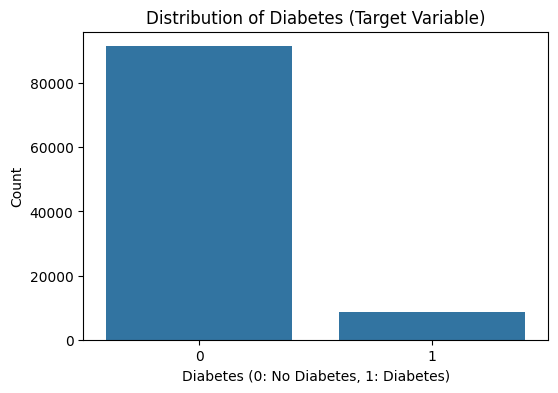


Percentage distribution of 'diabetes' target variable:
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64

**Reasoning and Implications of Class Imbalance**:
The plot and percentages clearly show a significant class imbalance: approximately 91.50% of the dataset represents non-diabetic individuals (0), while only 8.50% represents diabetic individuals (1). This imbalance is a critical observation as it can lead to misleading model performance if not handled properly. Traditional accuracy metrics can be deceptive; a model that simply predicts '0' for every instance would achieve a high accuracy due to the dominance of the majority class.

Therefore, for this project, we must focus on evaluation metrics more suitable for imbalanced datasets, such as Precision, Recall (Sensitivity), F1-score, and the Confusion Matrix. These metrics provide a more nuanced understanding of how well the model identifies both classes, especially the minority (diabetic) class, which is often of grea

In [ ]:
# Plot the distribution of the 'diabetes' target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='diabetes', data=df)
plt.title('Distribution of Diabetes (Target Variable)')
plt.xlabel('Diabetes (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Count')
plt.show()

# Calculate and print the percentage of each class
diabetes_counts = df['diabetes'].value_counts(normalize=True) * 100
print("\nPercentage distribution of 'diabetes' target variable:")
print(diabetes_counts)

# Reasoning for Imbalance
print("\n**Reasoning and Implications of Class Imbalance**:")
print("The plot and percentages clearly show a significant class imbalance: approximately {0:.2f}% of the dataset represents non-diabetic individuals (0), while only {1:.2f}% represents diabetic individuals (1). This imbalance is a critical observation as it can lead to misleading model performance if not handled properly. Traditional accuracy metrics can be deceptive; a model that simply predicts '0' for every instance would achieve a high accuracy due to the dominance of the majority class.\n\nTherefore, for this project, we must focus on evaluation metrics more suitable for imbalanced datasets, such as Precision, Recall (Sensitivity), F1-score, and the Confusion Matrix. These metrics provide a more nuanced understanding of how well the model identifies both classes, especially the minority (diabetic) class, which is often of greater interest in medical diagnoses.".format(diabetes_counts[0], diabetes_counts[1]))


Analyzing numerical feature: age


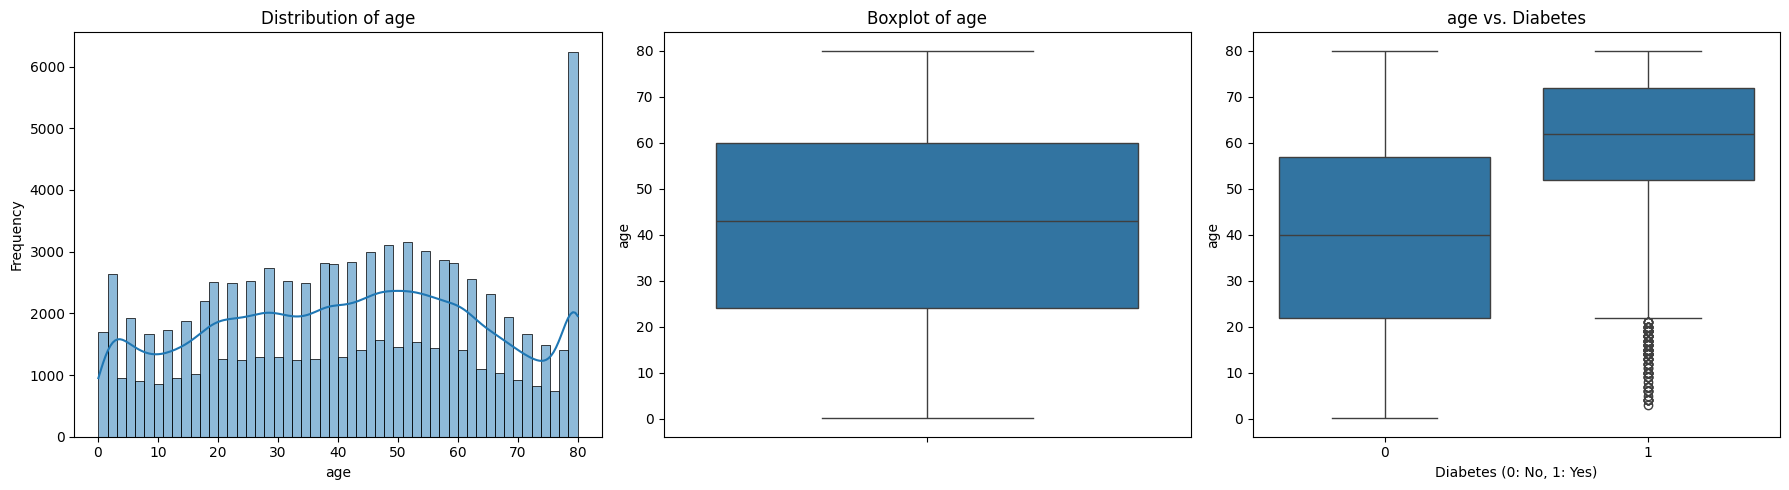


Analyzing numerical feature: bmi


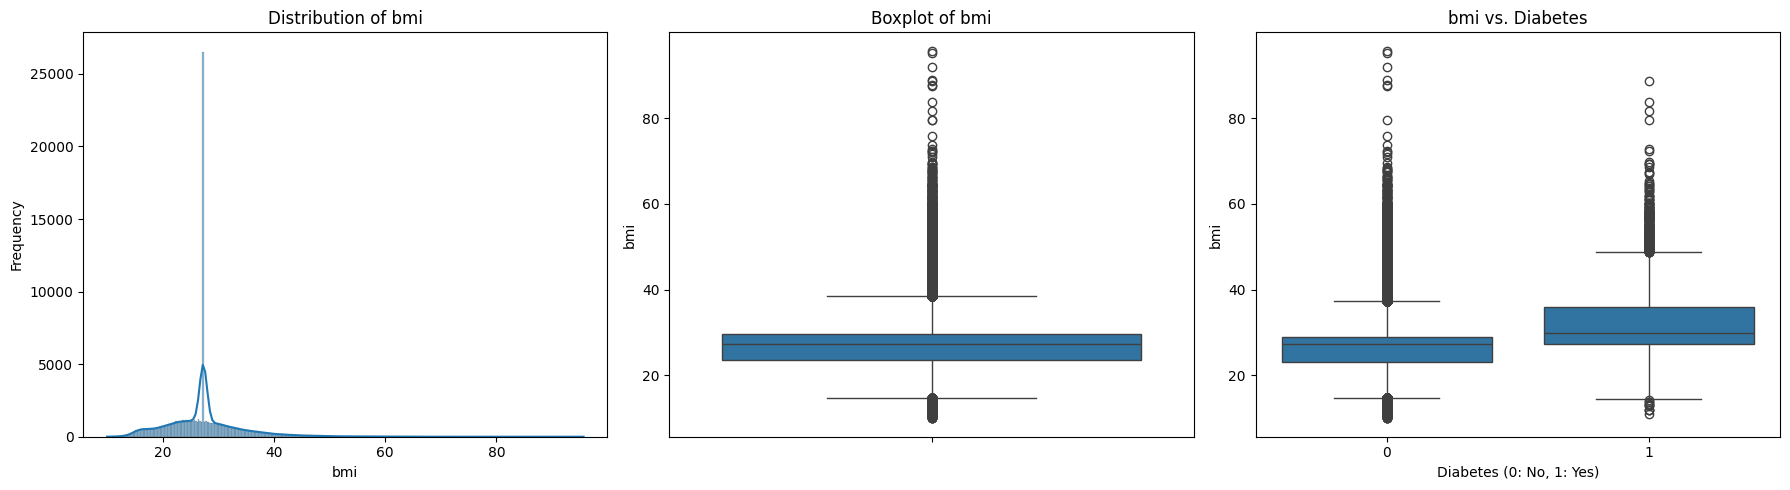


Analyzing numerical feature: HbA1c_level


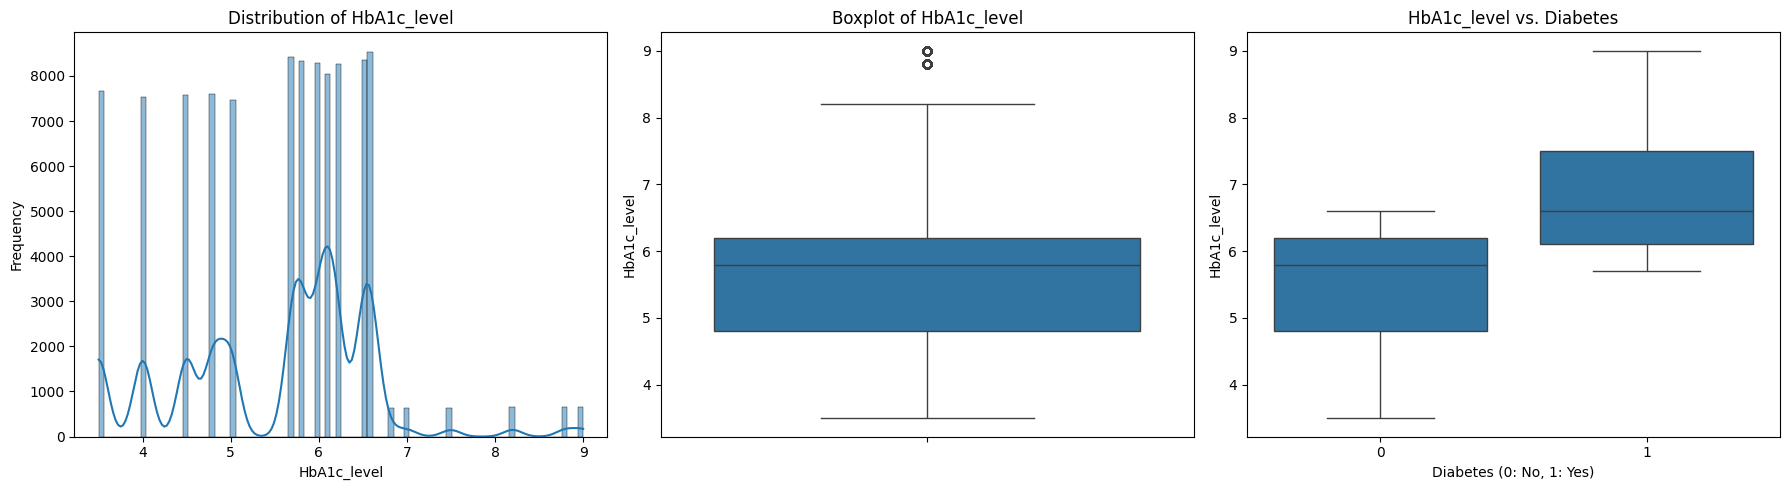


Analyzing numerical feature: blood_glucose_level


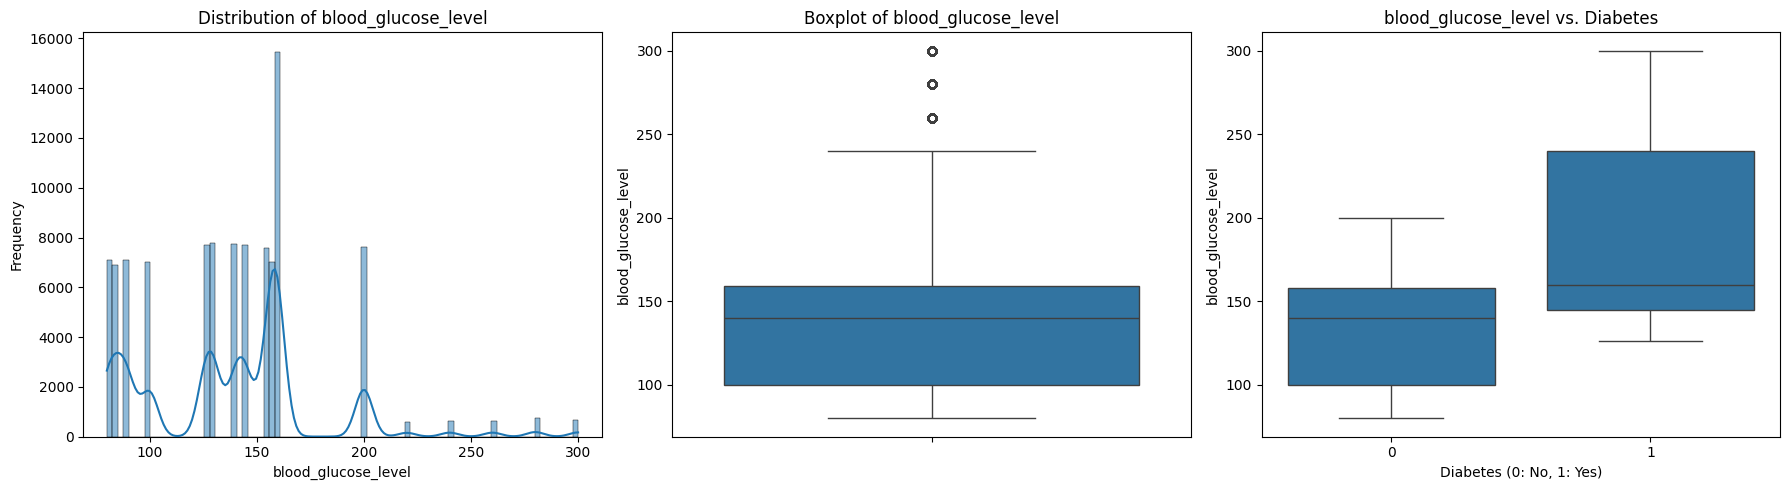

In [ ]:
numerical_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

for feature in numerical_features:
    print(f"\nAnalyzing numerical feature: {feature}")
    plt.figure(figsize=(18, 5))

    # Histogram and KDE plot
    plt.subplot(1, 3, 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # Boxplot to check for outliers
    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature)

    # Grouped Boxplot against 'diabetes'
    plt.subplot(1, 3, 3)
    sns.boxplot(x='diabetes', y=feature, data=df)
    plt.title(f'{feature} vs. Diabetes')
    plt.xlabel('Diabetes (0: No, 1: Yes)')
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()


Analyzing categorical feature: gender


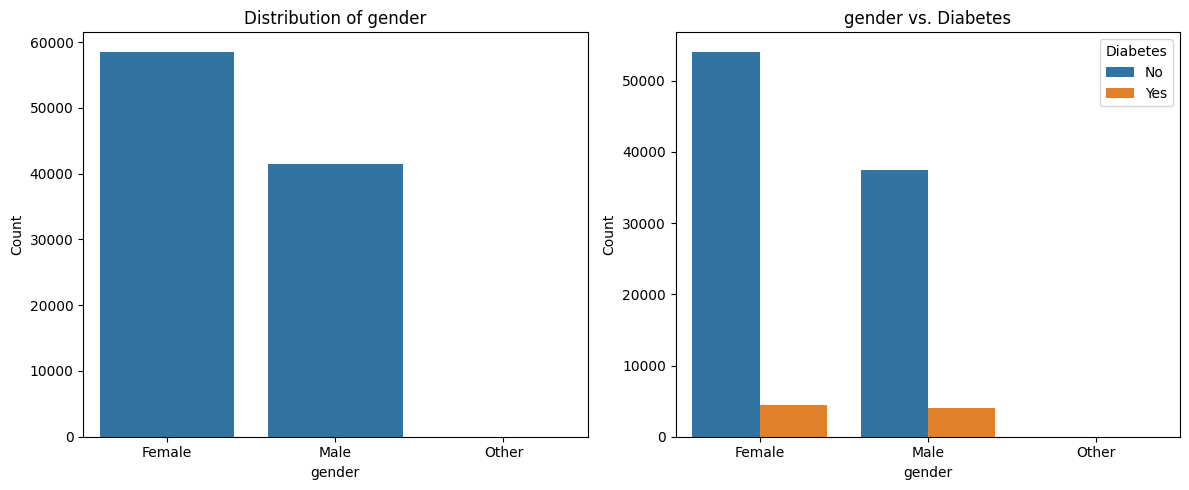


Crosstab for gender vs. Diabetes:
diabetes      0     1
gender               
Female    54091  4461
Male      37391  4039
Other        18     0

Normalized Crosstab (Proportion of Diabetes within each category):
diabetes         0         1
gender                      
Female    0.923811  0.076189
Male      0.902510  0.097490
Other     1.000000  0.000000

Analyzing categorical feature: smoking_history


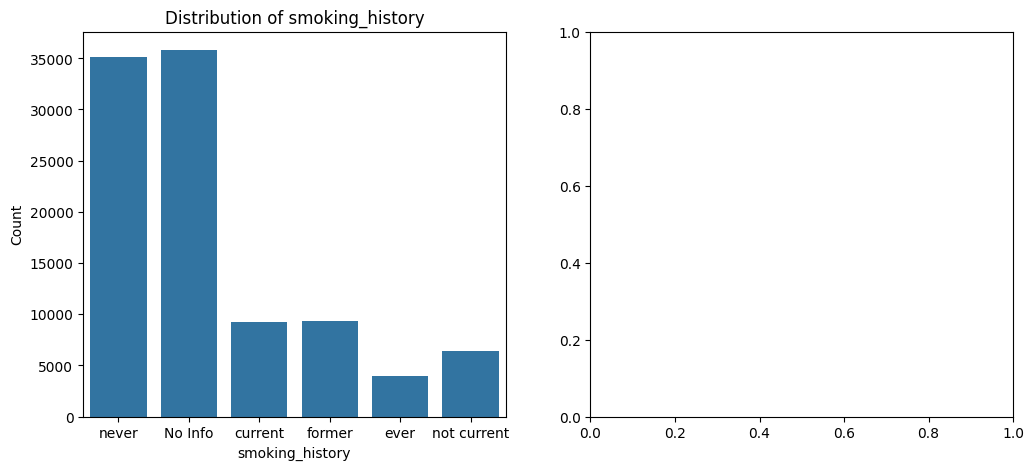

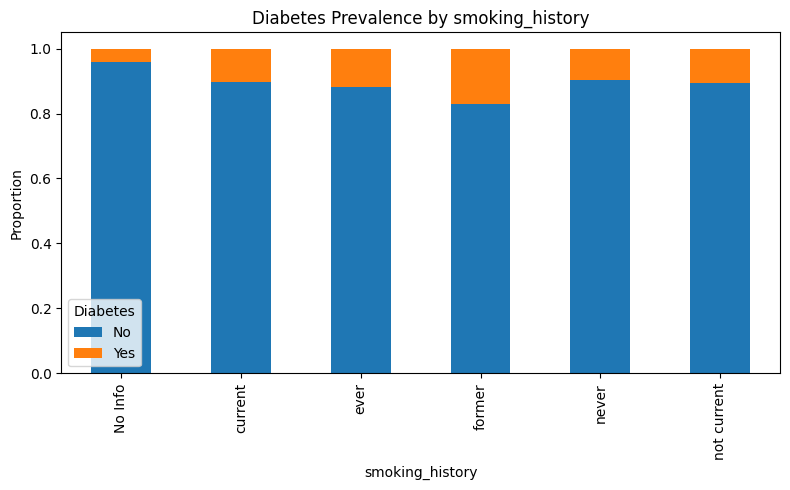


Crosstab for smoking_history vs. Diabetes:
diabetes             0     1
smoking_history             
No Info          34362  1454
current           8338   948
ever              3532   472
former            7762  1590
never            31749  3346
not current       5757   690

Normalized Crosstab (Proportion of Diabetes within each category):
diabetes                0         1
smoking_history                    
No Info          0.959404  0.040596
current          0.897911  0.102089
ever             0.882118  0.117882
former           0.829983  0.170017
never            0.904659  0.095341
not current      0.892973  0.107027

Analyzing categorical feature: hypertension


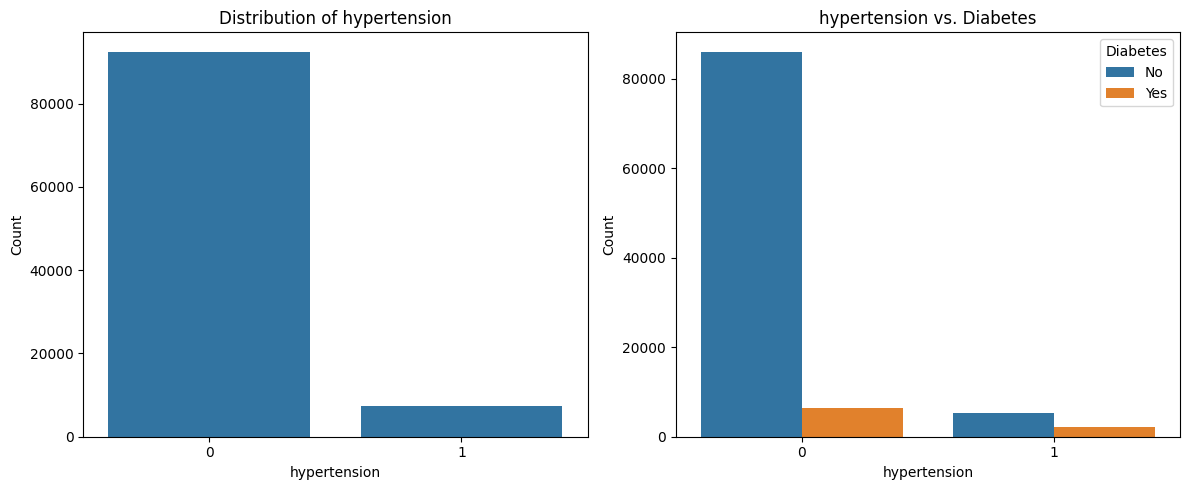


Crosstab for hypertension vs. Diabetes:
diabetes          0     1
hypertension             
0             86103  6412
1              5397  2088

Normalized Crosstab (Proportion of Diabetes within each category):
diabetes             0         1
hypertension                    
0             0.930692  0.069308
1             0.721042  0.278958

Analyzing categorical feature: heart_disease


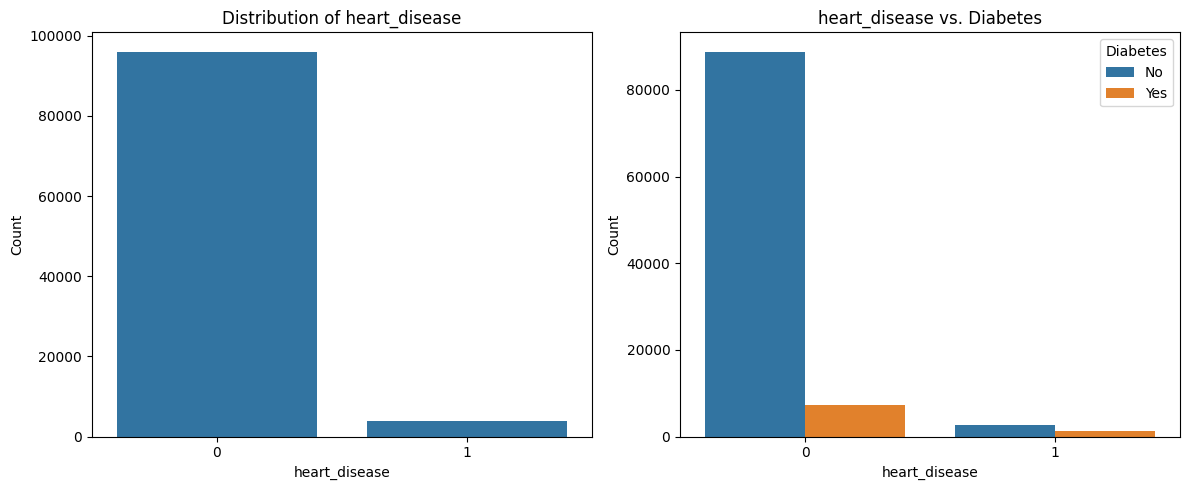


Crosstab for heart_disease vs. Diabetes:
diabetes           0     1
heart_disease             
0              88825  7233
1               2675  1267

Normalized Crosstab (Proportion of Diabetes within each category):
diabetes              0         1
heart_disease                    
0              0.924702  0.075298
1              0.678590  0.321410


In [ ]:
categorical_features = ['gender', 'smoking_history', 'hypertension', 'heart_disease']

for feature in categorical_features:
    print(f"\nAnalyzing categorical feature: {feature}")
    plt.figure(figsize=(12, 5))

    # Countplot for distribution
    plt.subplot(1, 2, 1)
    sns.countplot(x=feature, data=df)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')

    # Stacked bar chart or crosstab against diabetes
    plt.subplot(1, 2, 2)
    # For binary/simple categoricals, countplot with hue is effective
    if df[feature].nunique() <= 5: # Heuristic for number of unique values
        sns.countplot(x=feature, hue='diabetes', data=df)
        plt.title(f'{feature} vs. Diabetes')
        plt.xlabel(feature)
        plt.ylabel('Count')
        plt.legend(title='Diabetes', labels=['No', 'Yes'])
    else: # For features with more categories, a normalized crosstab might be better
        ct = pd.crosstab(df[feature], df['diabetes'], normalize='index')
        ct.plot(kind='bar', stacked=True, figsize=(8, 5))
        plt.title(f'Diabetes Prevalence by {feature}')
        plt.xlabel(feature)
        plt.ylabel('Proportion')
        plt.legend(title='Diabetes', labels=['No', 'Yes'])

    plt.tight_layout()
    plt.show()

    # Also print crosstab for detailed numbers
    print(f"\nCrosstab for {feature} vs. Diabetes:")
    print(pd.crosstab(df[feature], df['diabetes']))
    print("\nNormalized Crosstab (Proportion of Diabetes within each category):")
    print(pd.crosstab(df[feature], df['diabetes'], normalize='index'))

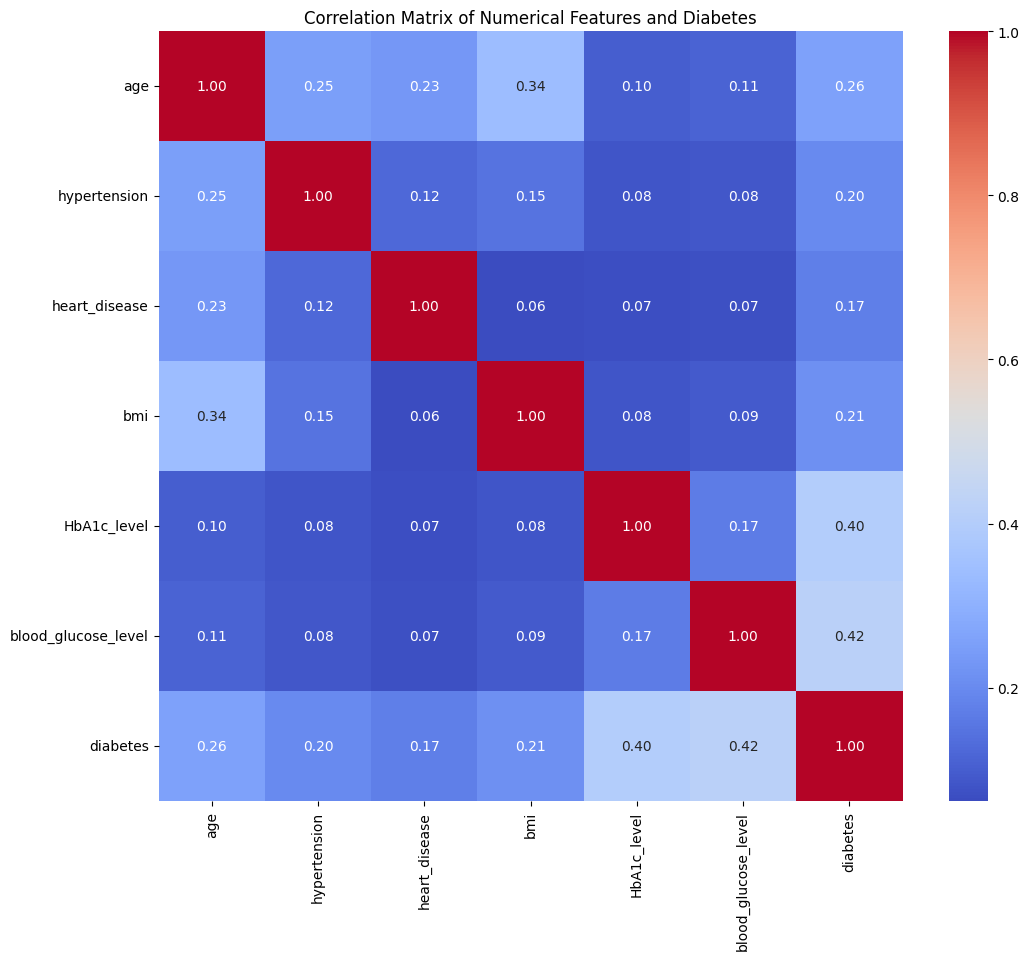


Discussion of Correlations:
From the correlation matrix, we can observe the following significant relationships with the 'diabetes' target variable:
- 'blood_glucose_level' shows a strong positive correlation with 'diabetes': 0.42
- 'HbA1c_level' also exhibits a strong positive correlation with 'diabetes': 0.40
These strong correlations are expected, as high blood glucose levels and high HbA1c levels are direct indicators of diabetes. The model will likely leverage these features significantly for prediction.
- 'age' has a moderate positive correlation with 'diabetes': 0.26
- 'bmi' has a weak positive correlation with 'diabetes': 0.21
- 'hypertension' and 'heart_disease' show positive correlations, as expected for risk factors: 0.20 and 0.17 respectively.


In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Diabetes')
plt.show()

# Discuss specific correlations
print("\nDiscussion of Correlations:")
print("From the correlation matrix, we can observe the following significant relationships with the 'diabetes' target variable:")
print(f"- 'blood_glucose_level' shows a strong positive correlation with 'diabetes': {correlation_matrix.loc['blood_glucose_level', 'diabetes']:.2f}")
print(f"- 'HbA1c_level' also exhibits a strong positive correlation with 'diabetes': {correlation_matrix.loc['HbA1c_level', 'diabetes']:.2f}")
print("These strong correlations are expected, as high blood glucose levels and high HbA1c levels are direct indicators of diabetes. The model will likely leverage these features significantly for prediction.")
print(f"- 'age' has a moderate positive correlation with 'diabetes': {correlation_matrix.loc['age', 'diabetes']:.2f}")
print(f"- 'bmi' has a weak positive correlation with 'diabetes': {correlation_matrix.loc['bmi', 'diabetes']:.2f}")
print(f"- 'hypertension' and 'heart_disease' show positive correlations, as expected for risk factors: {correlation_matrix.loc['hypertension', 'diabetes']:.2f} and {correlation_matrix.loc['heart_disease', 'diabetes']:.2f} respectively.")

## preprocessing

In [ ]:
df = df.drop_duplicates() #shal el duplicated rows
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (96146, 9)


In [ ]:
# Handle rare category: replace 'Other' with 'Unknown'
df['gender'] = df['gender'].replace('Other', 'Unknown')

# Check updated distribution
print("Gender value counts after handling 'Other':")
print(df['gender'].value_counts())

Gender value counts after handling 'Other':
gender
Female     56161
Male       39967
Unknown       18
Name: count, dtype: int64


In [ ]:
#feature engineering
df['bmi_default_flag'] = (df['bmi'] == 27.32).astype(int)
print("BMI default flag count:", df['bmi_default_flag'].sum())

print("\nUpdated DataFrame preview:")
print(df.head())

BMI default flag count: 21666

Updated DataFrame preview:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  bmi_default_flag  
0          6.6                  140         0                 0  
1          6.6                   80         0                 1  
2          5.7                  158         0                 1  
3          5.0                  155         0                 0  
4          4.8                  155         0                 0  


In [ ]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Split into Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("=== DATA SPLIT SHAPES ===")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\n=== CLASS DISTRIBUTION ===")
print("Train:\n", y_train.value_counts(normalize=True))
print("Validation:\n", y_val.value_counts(normalize=True))
print("Test:\n", y_test.value_counts(normalize=True))

=== DATA SPLIT SHAPES ===
Train: (67302, 9)
Validation: (14422, 9)
Test: (14422, 9)

=== CLASS DISTRIBUTION ===
Train:
 diabetes
0    0.911786
1    0.088214
Name: proportion, dtype: float64
Validation:
 diabetes
0    0.911732
1    0.088268
Name: proportion, dtype: float64
Test:
 diabetes
0    0.911801
1    0.088199
Name: proportion, dtype: float64


In [ ]:
# Identify categorical and numerical features
categorical_features = ['gender', 'smoking_history']

numerical_features = [
    'age',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level',
    'hypertension',
    'heart_disease',
    'bmi_default_flag',
]

# Create a column transformer for preprocessing
# One-hot encode categorical features and scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [ ]:
# --- Fit only on training data ---
print("Fitting preprocessing pipeline on training data...")

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)
# Get feature names after fitting the preprocessor
all_feature_names = preprocessor.get_feature_names_out()
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=all_feature_names,
    index=X_train.index
)

# Transform validation and test data
X_val_processed = preprocessor.transform(X_val)
X_val_processed_df = pd.DataFrame(
    X_val_processed,
    columns=all_feature_names,
    index=X_val.index
)
X_test_processed = preprocessor.transform(X_test)
X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=all_feature_names,
    index=X_test.index
)

print(X_train_processed_df.shape)
print(X_val_processed_df.shape)
print(X_test_processed_df.shape)

display(X_train_processed_df.head())

Fitting preprocessing pipeline on training data...
(67302, 16)
(14422, 16)
(14422, 16)


,num__age,num__bmi,num__HbA1c_level,num__blood_glucose_level,num__hypertension,num__heart_disease,num__bmi_default_flag,cat__gender_Female,cat__gender_Male,cat__gender_Unknown,cat__smoking_history_No Info,cat__smoking_history_current,cat__smoking_history_ever,cat__smoking_history_former,cat__smoking_history_never,cat__smoking_history_not current
70233,0.812805,-0.242387,0.437425,-1.175747,-0.290752,-0.206362,-0.539207,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
95154,-0.612356,-0.288324,-1.890696,0.535126,-0.290752,-0.206362,-0.539207,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
55028,-0.478747,0.002115,0.623674,1.512767,-0.290752,-0.206362,1.854574,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
19688,-1.725764,-1.162604,-0.680073,0.412920,-0.290752,-0.206362,-0.539207,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1674,0.144761,-1.036649,0.623674,-0.198106,-0.290752,4.845860,-0.539207,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
# ==============================
# SMOTE for Imbalanced Training Data
# ==============================

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE ONLY to the training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed_df,
    y_train
)

print("--- Imbalance Handling with SMOTE ---")

# Display balanced class distribution
print("Class distribution after SMOTE on training data:")
print(y_train_smote.value_counts())

# Display resulting dataset shapes
print(f"\nShape of X_train_smote: {X_train_smote.shape}")
print(f"Shape of y_train_smote: {y_train_smote.shape}")

--- Imbalance Handling with SMOTE ---
Class distribution after SMOTE on training data:
diabetes
0    61365
1    61365
Name: count, dtype: int64

Shape of X_train_smote: (122730, 16)
Shape of y_train_smote: (122730,)


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)

X_train_selected = selector.fit_transform(X_train_processed, y_train)
X_val_selected = selector.transform(X_val_processed)
X_test_selected = selector.transform(X_test_processed)

model evaluation func


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    average_precision_score
)

def evaluate_model(y_true, y_pred, y_probs=None, model_name=None):

    # Main Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Additional Metrics
    sensitivity = recall
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    # Optional PR-AUC
    if y_probs is not None:
        pr_auc = average_precision_score(y_true, y_probs)

    # Prints
    if model_name:
        print(f"===== {model_name} =====")

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall / Sensitivity: {sensitivity:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"F1 Score: {f1:.4f}")

    if y_probs is not None:
        print(f"PR-AUC: {pr_auc:.4f}")

    return accuracy, precision, recall, f1

## Principal Component Analysis (PCA)

Original number of features: 16
Number of components capturing 95% variance: 9
Cumulative explained variance: 0.96

Discussion of PCA Results:
PCA was applied to the processed training data. We found that 9 components are sufficient to explain 95% of the variance from the original 16 features. This reduction from 16 to 9 dimensions significantly reduces complexity while preserving most of the information.

--- PCA Visualization (Training Data) ---


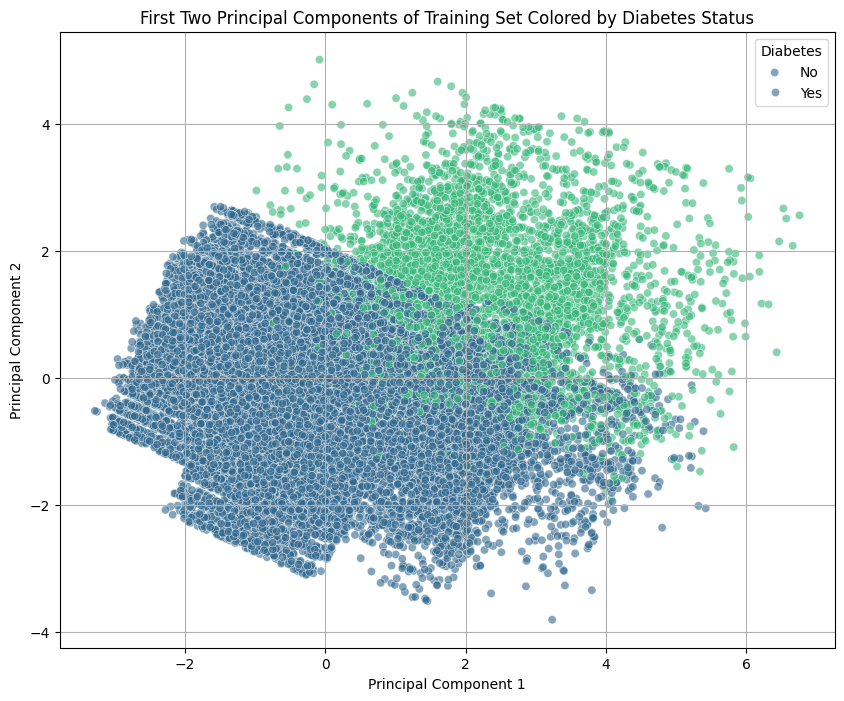

In [ ]:
# Initialize PCA to retain 95% of the variance
pca = PCA(n_components=0.95, random_state=42)

# Fit and transform training data (using the ndarray X_train_processed)
X_train_pca = pca.fit_transform(X_train_processed)

# Transform validation and test data
X_val_pca = pca.transform(X_val_processed)
X_test_pca = pca.transform(X_test_processed)

print(f"Original number of features: {X_train_processed.shape[1]}")
print(f"Number of components capturing 95% variance: {pca.n_components_}")
print(f"Cumulative explained variance: {pca.explained_variance_ratio_.sum():.2f}")

print("\nDiscussion of PCA Results:")
print(f"PCA was applied to the processed training data. We found that {pca.n_components_} components are sufficient to explain "
      f"95% of the variance from the original {X_train_processed.shape[1]} features. This reduction from {X_train_processed.shape[1]} to "
      f"{pca.n_components_} dimensions significantly reduces complexity while preserving most of the information.")

# --- PCA Visualization (2 components on Training Data) ---
print("\n--- PCA Visualization (Training Data) ---")
pca_vis = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_vis.fit_transform(X_train_processed) # Fit and transform on non-SMOTEd training data

# Create a DataFrame for plotting
X_train_pca_2d_df = pd.DataFrame(X_train_pca_2d, columns=['PC1', 'PC2'])
X_train_pca_2d_df['diabetes'] = y_train.reset_index(drop=True) # Attach target variable

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='diabetes',
    data=X_train_pca_2d_df,
    palette='viridis',
    alpha=0.6
)
plt.title('First Two Principal Components of Training Set Colored by Diabetes Status')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Diabetes', labels=['No', 'Yes'])
plt.grid(True)
plt.show()

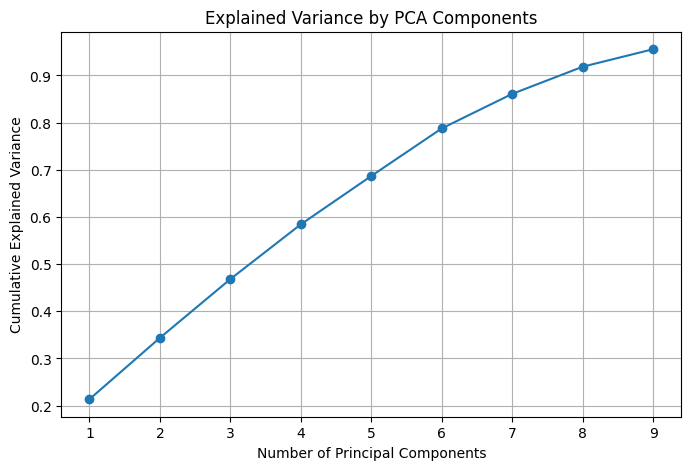

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

## ***models***




In [ ]:
# Dictionary to store all model results
results = {}

### **Naive bayes**

#### Naive Bayes without pca

In [ ]:
# ==============================
# Naive Bayes WITHOUT PCA, WITH SMOTE
# ==============================

smote_nb = SMOTE(random_state=42)
X_train_smote_nb, y_train_smote_nb = smote_nb.fit_resample(X_train_selected, y_train)

nb_model_smote = GaussianNB()
nb_model_smote.fit(X_train_smote_nb, y_train_smote_nb)
y_test_pred_smote = nb_model_smote.predict(X_test_selected)

print("\n===== Naive Bayes (WITHOUT PCA, WITH SMOTE) =====")
evaluate_model(y_test, y_test_pred_smote)
nb_smote_acc = accuracy_score(y_test, y_test_pred_smote)
nb_smote_f1 = f1_score(y_test, y_test_pred_smote)


===== Naive Bayes (WITHOUT PCA, WITH SMOTE) =====
Confusion Matrix:
[[11515  1635]
 [  255  1017]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.92     13150
           1       0.38      0.80      0.52      1272

    accuracy                           0.87     14422
   macro avg       0.68      0.84      0.72     14422
weighted avg       0.93      0.87      0.89     14422

Accuracy: 0.8690
Precision: 0.3835
Recall / Sensitivity: 0.7995
Balanced Accuracy: 0.8376
F1 Score: 0.5183


#### curves for naive bayes

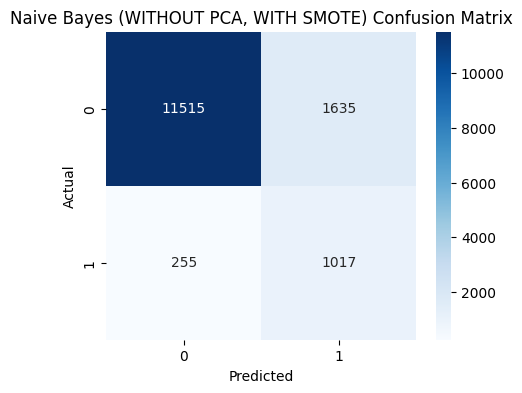

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_smote)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Naive Bayes (WITHOUT PCA, WITH SMOTE) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### **XGBoosting**

#### XGBoost without pca

In [ ]:
import numpy as np

# 1. Initialize model
xgb_model_smote = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

# 2. Train on SMOTE data (no feature selection)
xgb_model_smote.fit(X_train_smote, y_train_smote)

# 3. Predict on Validation Data
y_val_pred_xgb_smote = xgb_model_smote.predict(X_val_processed)

# 4. Evaluate on Validation Data
print("===== XGBoost (WITHOUT PCA, WITH SMOTE) - Validation ====")
xgb_val_acc, xgb_val_precision, xgb_val_recall, xgb_val_f1 = evaluate_model(y_val, y_val_pred_xgb_smote)

# Save validation results
results["XGBoost (No PCA) - Validation"] = {
    "Accuracy": xgb_val_acc,
    "F1 Score": xgb_val_f1,
    "Precision": xgb_val_precision,
    "Recall": xgb_val_recall
}

# 5. Predict on Test Data
y_test_pred_xgb_smote = xgb_model_smote.predict(X_test_processed)

# 6. Evaluate on Test Data
print("\n===== XGBoost (WITHOUT PCA, WITH SMOTE) - Test ====")
xgb_test_acc, xgb_test_precision, xgb_test_recall, xgb_test_f1 = evaluate_model(y_test, y_test_pred_xgb_smote)

# Save test results
results["XGBoost (No PCA)"] = {
    "Accuracy": xgb_test_acc,
    "F1 Score": xgb_test_f1,
    "Precision": xgb_test_precision,
    "Recall": xgb_test_recall
}

===== XGBoost (WITHOUT PCA, WITH SMOTE) - Validation ====
Confusion Matrix:
[[13066    83]
 [  378   895]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13149
           1       0.92      0.70      0.80      1273

    accuracy                           0.97     14422
   macro avg       0.94      0.85      0.89     14422
weighted avg       0.97      0.97      0.97     14422

Accuracy: 0.9680
Precision: 0.9151
Recall / Sensitivity: 0.7031
Balanced Accuracy: 0.8484
F1 Score: 0.7952

===== XGBoost (WITHOUT PCA, WITH SMOTE) - Test ====
Confusion Matrix:
[[13044   106]
 [  341   931]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13150
           1       0.90      0.73      0.81      1272

    accuracy                           0.97     14422
   macro avg       0.94      0.86      0.89     14422
weighted avg       0.97      0.97    

#### curves for XGBOOST

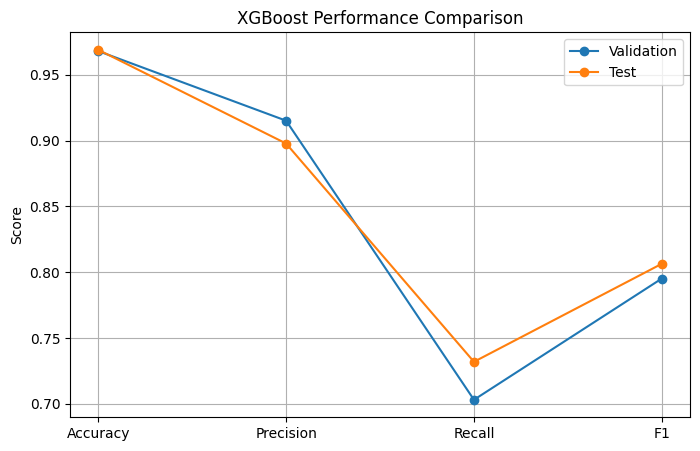

In [ ]:
import numpy as np

labels = ['Accuracy', 'Precision', 'Recall', 'F1']

# Retrieve scores from the results dictionary
validation_scores = [
    results["XGBoost (No PCA) - Validation"]["Accuracy"],
    results["XGBoost (No PCA) - Validation"]["Precision"],
    results["XGBoost (No PCA) - Validation"]["Recall"],
    results["XGBoost (No PCA) - Validation"]["F1 Score"]
]
test_scores = [
    results["XGBoost (No PCA)"]["Accuracy"],
    results["XGBoost (No PCA)"]["Precision"],
    results["XGBoost (No PCA)"]["Recall"],
    results["XGBoost (No PCA)"]["F1 Score"]
]

x = np.arange(len(labels))

plt.figure(figsize=(8,5))

plt.plot(labels, validation_scores, marker='o', label='Validation')
plt.plot(labels, test_scores, marker='o', label='Test')

plt.title("XGBoost Performance Comparison")
plt.ylabel("Score")
plt.legend()
plt.grid(True)

plt.show()

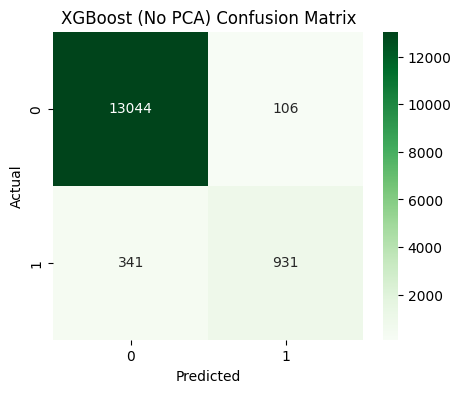

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_xgb_smote)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("XGBoost (No PCA) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

###**Logistic Regression**


In [ ]:
# ==============================================================================
# Logistic Regression (WITHOUT PCA) + SMOTE
# ==============================================================================
import numpy as np
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print("Initiating SMOTE and Threshold Optimization Loop (F1 Focus)...")

# Tracking variables to find our absolute best F1 balance
best_f1_val = 0
best_ratio = 0.2
best_threshold = 0.3

# Loop over SMOTE sampling ratios from 20% to 50% of the majority class size
for ratio in np.arange(0.20, 0.55, 0.05):
    ratio = round(ratio, 2)

    # Rebuild pipeline with the current SMOTE ratio
    temp_pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(sampling_strategy=ratio, random_state=42)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])

    temp_pipeline.fit(X_train, y_train)
    val_probs = temp_pipeline.predict_proba(X_val)[:, 1]

    # Loop over custom thresholds from 0.25 to 0.55
    for thresh in np.arange(0.25, 0.56, 0.02):
        thresh = round(thresh, 2)
        val_preds = (val_probs >= thresh).astype(int)

        # Calculate metrics on the validation set
        current_f1 = f1_score(y_val, val_preds)
        current_prec = precision_score(y_val, val_preds, zero_division=0)

        # Guardrail: Ensure precision doesn't tank while chasing the best F1
        if current_prec >= 0.70:
            # Maximizing F1 Score directly
            if current_f1 > best_f1_val:
                best_f1_val = current_f1
                best_ratio = ratio
                best_threshold = thresh

print(f"\nOptimization Complete!")
print(f"-> Selected SMOTE Ratio: {best_ratio}")
print(f"-> Selected Threshold: {best_threshold}")
print(f"-> Highest Validation F1 Achieved: {best_f1_val:.4f}")

# --- Train Final Optimized Pipeline ---
lr_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=best_ratio, random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

# Predict probabilities using final model
y_val_probs_lr = lr_pipeline.predict_proba(X_val)[:, 1]
y_test_probs_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Convert probabilities to predictions using optimal threshold
y_val_pred_lr = (y_val_probs_lr >= best_threshold).astype(int)
y_test_pred_lr = (y_test_probs_lr >= best_threshold).astype(int)

# Evaluation
print("\n===== Logistic Regression Pipeline (WITHOUT PCA) =====")
print(f"Using Custom Threshold = {best_threshold} and SMOTE Ratio = {best_ratio}")

# Validation Results
print("\n===== Validation Results =====")
evaluate_model(y_val, y_val_pred_lr, y_val_probs_lr)

# Test Results
print("\n===== Test Results =====")
evaluate_model(y_test, y_test_pred_lr, y_test_probs_lr)

# Save results
lr_acc = accuracy_score(y_test, y_test_pred_lr)

lr_precision = precision_score(
    y_test,
    y_test_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_test_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_test_pred_lr
)

results["Logistic Regression (No PCA)"] = {
    "Accuracy": lr_acc,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1 Score": lr_f1
}

print("\n=== Saved Logistic Regression Pipeline Results (WITHOUT PCA) ===")
print("Accuracy:", lr_acc)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

Initiating SMOTE and Threshold Optimization Loop (F1 Focus)...

Optimization Complete!
-> Selected SMOTE Ratio: 0.2
-> Selected Threshold: 0.51
-> Highest Validation F1 Achieved: 0.7004

===== Logistic Regression Pipeline (WITHOUT PCA) =====
Using Custom Threshold = 0.51 and SMOTE Ratio = 0.2

===== Validation Results =====
Confusion Matrix:
[[12832   317]
 [  416   857]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     13149
           1       0.73      0.67      0.70      1273

    accuracy                           0.95     14422
   macro avg       0.85      0.82      0.84     14422
weighted avg       0.95      0.95      0.95     14422

Accuracy: 0.9492
Precision: 0.7300
Recall / Sensitivity: 0.6732
Balanced Accuracy: 0.8246
F1 Score: 0.7004
PR-AUC: 0.7971

===== Test Results =====
Confusion Matrix:
[[12852   298]
 [  346   926]]

Classification Report:
              precision    recall  f1-score   support

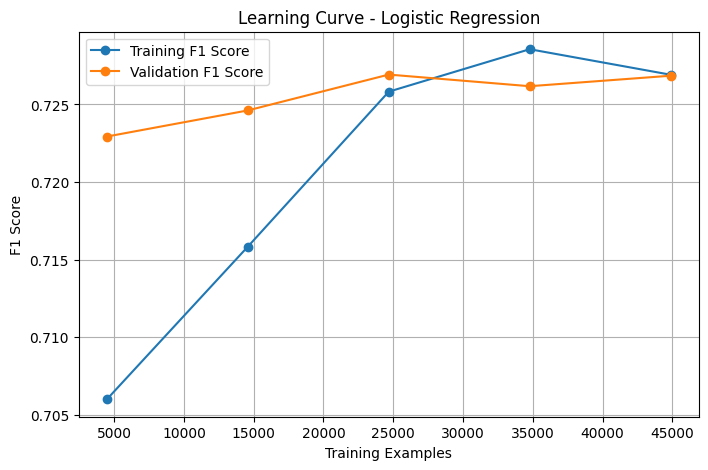

In [ ]:
# ==========================================
# Logistic Regression Learning Curve
# ==========================================

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=lr_pipeline,
    X=X_train,
    y=y_train,
    cv=3,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Mean scores
train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_scores_mean,
    marker='o',
    label='Training F1 Score'
)

plt.plot(
    train_sizes,
    val_scores_mean,
    marker='o',
    label='Validation F1 Score'
)

plt.title("Learning Curve - Logistic Regression")
plt.xlabel("Training Examples")
plt.ylabel("F1 Score")

plt.legend()
plt.grid(True)

plt.show()

### **MLP Model**

#### MLP without PCA

In [ ]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation='logistic',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Train
mlp_model.fit(X_train_processed, y_train)

# Predict
y_test_pred_mlp = mlp_model.predict(X_test_processed)

print("===== MLP (WITHOUT PCA) =====")

# Evaluation
evaluate_model(y_test, y_test_pred_mlp)

# Save metrics
mlp_acc = accuracy_score(y_test,y_test_pred_mlp)

mlp_precision = precision_score(
    y_test,
    y_test_pred_mlp
)

mlp_recall = recall_score(
    y_test,
    y_test_pred_mlp
)

mlp_f1 = f1_score(
    y_test,
    y_test_pred_mlp
)

results["MLP (No PCA)"] = {
    "Accuracy": mlp_acc,
    "Precision": mlp_precision,
    "Recall": mlp_recall,
    "F1 Score": mlp_f1
}

print("\n=== Saved MLP Results ===")
print("Accuracy:",mlp_acc)
print("Precision:",mlp_precision)
print("Recall:",mlp_recall)
print("F1:",mlp_f1)

===== MLP (WITHOUT PCA) =====
Confusion Matrix:
[[13100    50]
 [  372   900]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     13150
           1       0.95      0.71      0.81      1272

    accuracy                           0.97     14422
   macro avg       0.96      0.85      0.90     14422
weighted avg       0.97      0.97      0.97     14422

Accuracy: 0.9707
Precision: 0.9474
Recall / Sensitivity: 0.7075
Balanced Accuracy: 0.8519
F1 Score: 0.8101

=== Saved MLP Results ===
Accuracy: 0.9707391485230897
Precision: 0.9473684210526315
Recall: 0.7075471698113207
F1: 0.8100810081008101


#### MLP with SMOTE

In [ ]:
# Final MLP SMOTE model uses optimized ratio from validation tuning
smote = SMOTE(
    sampling_strategy=0.2,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

mlp_model_smote = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp_model_smote.fit(X_train_smote, y_train_smote)

y_test_pred_mlp_smote = mlp_model_smote.predict(X_test_processed)

print("===== MLP (WITH OPTIMIZED SMOTE: 0.2) =====")
evaluate_model(y_test, y_test_pred_mlp_smote)

mlp_smote_acc = accuracy_score(y_test, y_test_pred_mlp_smote)
mlp_smote_precision = precision_score(y_test, y_test_pred_mlp_smote)
mlp_smote_recall = recall_score(y_test, y_test_pred_mlp_smote)
mlp_smote_f1 = f1_score(y_test, y_test_pred_mlp_smote)

results["MLP (Optimized SMOTE)"] = {
    "Accuracy": mlp_smote_acc,
    "Precision": mlp_smote_precision,
    "Recall": mlp_smote_recall,
    "F1 Score": mlp_smote_f1
}

print("\n=== Saved MLP Results (OPTIMIZED SMOTE) ===")
print("SMOTE Ratio: 0.2")
print("Accuracy:", mlp_smote_acc)
print("Precision:", mlp_smote_precision)
print("Recall:", mlp_smote_recall)
print("F1 Score:", mlp_smote_f1)

===== MLP (WITH OPTIMIZED SMOTE: 0.2) =====
Confusion Matrix:
[[12934   216]
 [  308   964]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     13150
           1       0.82      0.76      0.79      1272

    accuracy                           0.96     14422
   macro avg       0.90      0.87      0.88     14422
weighted avg       0.96      0.96      0.96     14422

Accuracy: 0.9637
Precision: 0.8169
Recall / Sensitivity: 0.7579
Balanced Accuracy: 0.8707
F1 Score: 0.7863

=== Saved MLP Results (OPTIMIZED SMOTE) ===
SMOTE Ratio: 0.2
Accuracy: 0.9636666204409929
Precision: 0.8169491525423729
Recall: 0.7578616352201258
F1 Score: 0.7862969004893964


#### Compare MLP Models: No PCA vs PCA vs SMOTE

In [ ]:
mlp_compare_df = pd.DataFrame({
    "No PCA": results["MLP (No PCA)"],
    "Optimized SMOTE": results["MLP (Optimized SMOTE)"]
}).T

display(mlp_compare_df)

,Accuracy,Precision,Recall,F1 Score
No PCA,0.970739,0.947368,0.707547,0.810081
Optimized SMOTE,0.963667,0.816949,0.757862,0.786297


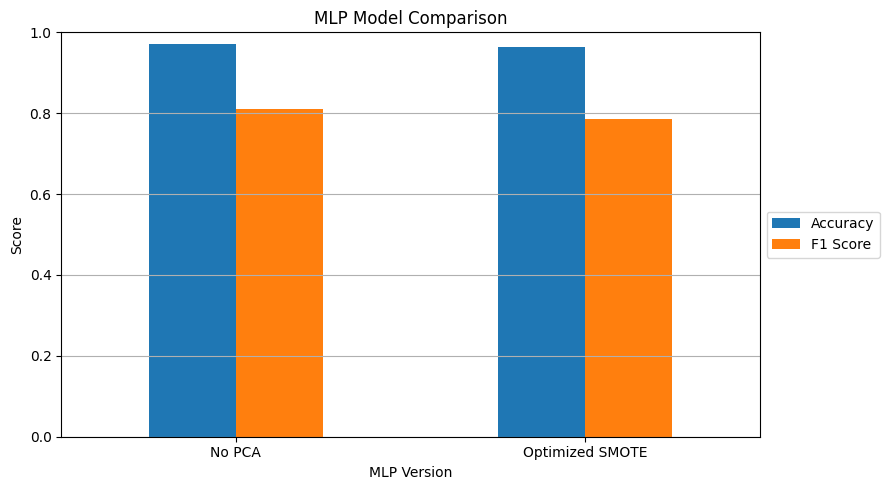

In [ ]:
mlp_compare_df[["Accuracy", "F1 Score"]].plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("MLP Model Comparison")
plt.ylabel("Score")
plt.xlabel("MLP Version")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

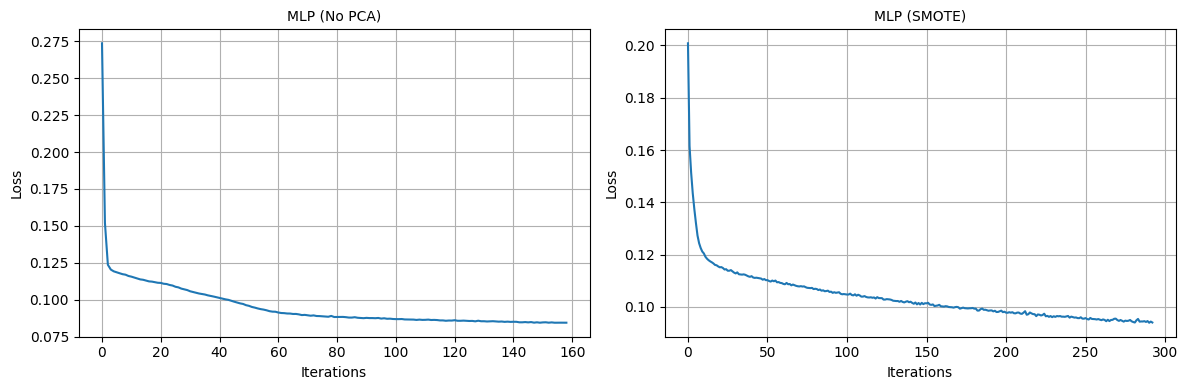

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

models = [
    ("MLP (No PCA)", mlp_model),
    ("MLP (SMOTE)", mlp_model_smote)
]

for ax, (title, model) in zip(axes, models):

    ax.plot(model.loss_curve_)

    ax.set_title(title, fontsize=10)

    ax.set_xlabel("Iterations")

    ax.set_ylabel("Loss")

    ax.grid(True)

plt.tight_layout()

plt.show()

#### Gradient Boosting without PCA

In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_processed, y_train)

y_test_pred_gb = gb_model.predict(X_test_processed)

print("===== Gradient Boosting (WITHOUT PCA) =====")

evaluate_model(y_test, y_test_pred_gb)

gb_acc = accuracy_score(y_test, y_test_pred_gb)
gb_precision = precision_score(y_test, y_test_pred_gb)
gb_recall = recall_score(y_test, y_test_pred_gb)
gb_f1 = f1_score(y_test, y_test_pred_gb)

results["Gradient Boosting (No PCA)"] = {
    "Accuracy": gb_acc,
    "Precision": gb_precision,
    "Recall": gb_recall,
    "F1 Score": gb_f1
}

print("\n=== Saved Gradient Boosting Results (WITHOUT PCA) ===")
print("Accuracy:", gb_acc)
print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1 Score:", gb_f1)

===== Gradient Boosting (WITHOUT PCA) =====
Confusion Matrix:
[[13138    12]
 [  376   896]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     13150
           1       0.99      0.70      0.82      1272

    accuracy                           0.97     14422
   macro avg       0.98      0.85      0.90     14422
weighted avg       0.97      0.97      0.97     14422

Accuracy: 0.9731
Precision: 0.9868
Recall / Sensitivity: 0.7044
Balanced Accuracy: 0.8517
F1 Score: 0.8220

=== Saved Gradient Boosting Results (WITHOUT PCA) ===
Accuracy: 0.9730966578837886
Precision: 0.986784140969163
Recall: 0.7044025157232704
F1 Score: 0.8220183486238533


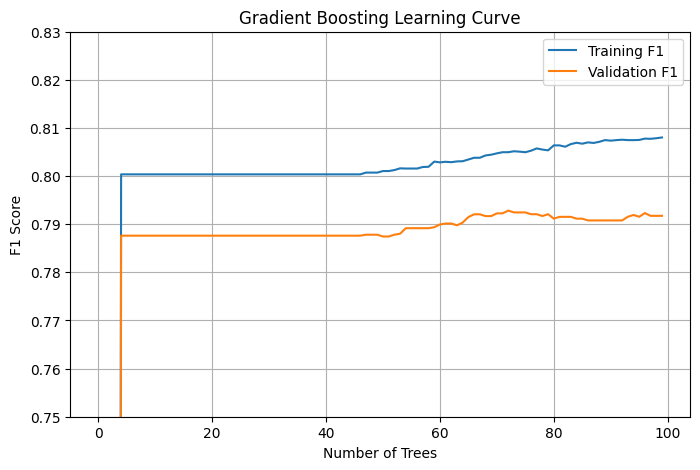

In [ ]:
train_scores = []
val_scores = []

for pred in gb_model.staged_predict(X_train_processed):
    train_scores.append(
        f1_score(y_train, pred)
    )

for pred in gb_model.staged_predict(X_val_processed):
    val_scores.append(
        f1_score(y_val, pred)
    )

plt.figure(figsize=(8,5))

plt.plot(train_scores,label="Training F1")
plt.plot(val_scores,label="Validation F1")

plt.title("Gradient Boosting Learning Curve")
plt.xlabel("Number of Trees")
plt.ylabel("F1 Score")

plt.ylim(0.75,0.83)

plt.legend()
plt.grid(True)

plt.show()



# Linear SVM


In [ ]:
# ==============================
# Linear SVM
# ==============================
param_grid_linear = {
    'C': [0.01, 0.1, 1, 10, 100]
}
linear_svm_grid = GridSearchCV(
    estimator=LinearSVC(
        random_state=42,
        max_iter=10000
    ),
    param_grid=param_grid_linear,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

linear_svm_grid.fit(X_train_processed, y_train)

best_linear_svm = linear_svm_grid.best_estimator_

print("===== Linear SVM WITHOUT PCA =====")
print("Best C:", linear_svm_grid.best_params_)
print("Best CV F1 Score:", linear_svm_grid.best_score_)

y_val_pred_linear_svm = best_linear_svm.predict(X_val_processed)
y_test_pred_linear_svm = best_linear_svm.predict(X_test_processed)

print("\n===== Validation Results =====")
evaluate_model(y_val, y_val_pred_linear_svm)

print("\n===== Test Results =====")
linear_svm_acc, linear_svm_precision, linear_svm_recall, linear_svm_f1 = evaluate_model(
    y_test,
    y_test_pred_linear_svm
)
# Save Linear SVM results without deleting previous models

results["Linear SVM (No PCA)"] = {
    "Accuracy": linear_svm_acc,
    "F1 Score": linear_svm_f1,
    "Precision": linear_svm_precision,
    "Recall": linear_svm_recall
}

===== Linear SVM WITHOUT PCA =====
Best C: {'C': 0.1}
Best CV F1 Score: 0.7270909320220073

===== Validation Results =====
Confusion Matrix:
[[13050    99]
 [  535   738]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     13149
           1       0.88      0.58      0.70      1273

    accuracy                           0.96     14422
   macro avg       0.92      0.79      0.84     14422
weighted avg       0.95      0.96      0.95     14422

Accuracy: 0.9560
Precision: 0.8817
Recall / Sensitivity: 0.5797
Balanced Accuracy: 0.7861
F1 Score: 0.6995

===== Test Results =====
Confusion Matrix:
[[13051    99]
 [  455   817]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13150
           1       0.89      0.64      0.75      1272

    accuracy                           0.96     14422
   macro avg       0.93      0.82      0.86     14422

# RBF SVM using Grid Search(with and without PCA):

RBF SVM without PCA using Grid Search:

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Take a smaller sample from the training data for tuning
X_train_svm_sample = X_train_processed[:15000]
y_train_svm_sample = y_train[:15000]

param_grid_rbf_full = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1]
}

rbf_svm_grid_full = GridSearchCV(
    estimator=SVC(
        kernel='rbf',
        random_state=42
    ),
    param_grid=param_grid_rbf_full,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

rbf_svm_grid_full.fit(X_train_svm_sample, y_train_svm_sample)

print("Best Parameters:", rbf_svm_grid_full.best_params_)
print("Best CV F1 Score:", rbf_svm_grid_full.best_score_)
best_params = rbf_svm_grid_full.best_params_

best_rbf_svm = SVC(
    kernel='rbf',
    C=best_params['C'],
    gamma=best_params['gamma'],
    random_state=42
)

best_rbf_svm.fit(X_train_processed, y_train)

y_val_pred_rbf_svm = best_rbf_svm.predict(X_val_processed)
y_test_pred_rbf_svm = best_rbf_svm.predict(X_test_processed)

print("===== RBF SVM WITHOUT PCA - Final Full Training =====")

print("\n===== Validation Results =====")
evaluate_model(y_val, y_val_pred_rbf_svm)

print("\n===== Test Results =====")
rbf_svm_acc, rbf_svm_precision, rbf_svm_recall, rbf_svm_f1 = evaluate_model(
    y_test,
    y_test_pred_rbf_svm
)

results["RBF SVM (No PCA)"] = {
    "Accuracy": rbf_svm_acc,
    "F1 Score": rbf_svm_f1,
    "Precision": rbf_svm_precision,
    "Recall": rbf_svm_recall
}

Best Parameters: {'C': 100, 'gamma': 0.1}
Best CV F1 Score: 0.7305227652285741
===== RBF SVM WITHOUT PCA - Final Full Training =====

===== Validation Results =====
Confusion Matrix:
[[13112    37]
 [  471   802]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     13149
           1       0.96      0.63      0.76      1273

    accuracy                           0.96     14422
   macro avg       0.96      0.81      0.87     14422
weighted avg       0.96      0.96      0.96     14422

Accuracy: 0.9648
Precision: 0.9559
Recall / Sensitivity: 0.6300
Balanced Accuracy: 0.8136
F1 Score: 0.7595

===== Test Results =====
Confusion Matrix:
[[13116    34]
 [  412   860]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     13150
           1       0.96      0.68      0.79      1272

    accuracy                           0.97     14422
   macro av

# RBF SVM using PSO :

In [ ]:
# ==============================
# RBF SVM WITHOUT PCA
# PSO Optimization for C and gamma
# ==============================

import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import f1_score

# Use a sample for PSO to keep it practical
X_train_svm_sample = X_train_processed[:15000]
y_train_svm_sample = y_train[:15000]

X_val_svm_sample = X_val_processed
y_val_svm_sample = y_val


# ==============================
# Objective Function
# ==============================

def svm_pso_objective(params):
    C = params[0]
    gamma = params[1]

    model = SVC(
        kernel='rbf',
        C=C,
        gamma=gamma,
        random_state=42
    )

    model.fit(X_train_svm_sample, y_train_svm_sample)
    y_pred = model.predict(X_val_svm_sample)

    f1 = f1_score(y_val_svm_sample, y_pred)

    # PSO minimizes, so return negative F1
    return -f1


# ==============================
# Simple PSO Implementation
# ==============================

np.random.seed(42)

n_particles = 5
n_iterations = 5

# C range: 0.1 to 100
# gamma range: 0.001 to 1
lower_bounds = np.array([0.1, 0.001])
upper_bounds = np.array([100, 1])

positions = np.random.uniform(
    lower_bounds,
    upper_bounds,
    size=(n_particles, 2)
)

velocities = np.zeros_like(positions)

personal_best_positions = positions.copy()
personal_best_scores = np.array([
    svm_pso_objective(p) for p in positions
])

global_best_index = np.argmin(personal_best_scores)
global_best_position = personal_best_positions[global_best_index].copy()
global_best_score = personal_best_scores[global_best_index]

w = 0.5
c1 = 1.5
c2 = 1.5

for iteration in range(n_iterations):
    for i in range(n_particles):
        r1 = np.random.rand(2)
        r2 = np.random.rand(2)

        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (personal_best_positions[i] - positions[i])
            + c2 * r2 * (global_best_position - positions[i])
        )

        positions[i] = positions[i] + velocities[i]
        positions[i] = np.clip(positions[i], lower_bounds, upper_bounds)

        score = svm_pso_objective(positions[i])

        if score < personal_best_scores[i]:
            personal_best_scores[i] = score
            personal_best_positions[i] = positions[i].copy()

    global_best_index = np.argmin(personal_best_scores)
    global_best_position = personal_best_positions[global_best_index].copy()
    global_best_score = personal_best_scores[global_best_index]

    print(f"Iteration {iteration + 1}/{n_iterations}")
    print("Best C:", global_best_position[0])
    print("Best gamma:", global_best_position[1])
    print("Best F1:", -global_best_score)
    print("--------------------")


best_C_pso = global_best_position[0]
best_gamma_pso = global_best_position[1]

print("===== Best PSO Parameters =====")
print("Best C:", best_C_pso)
print("Best gamma:", best_gamma_pso)
print("Best Validation F1:", -global_best_score)
# ==============================
# Final RBF SVM WITHOUT PCA using PSO parameters
# ==============================

rbf_svm_pso = SVC(
    kernel='rbf',
    C=best_C_pso,
    gamma=best_gamma_pso,
    random_state=42
)

rbf_svm_pso.fit(X_train_processed, y_train)

y_val_pred_rbf_svm_pso = rbf_svm_pso.predict(X_val_processed)
y_test_pred_rbf_svm_pso = rbf_svm_pso.predict(X_test_processed)

print("===== RBF SVM WITHOUT PCA - PSO =====")

print("\n===== Validation Results =====")
evaluate_model(y_val, y_val_pred_rbf_svm_pso)

print("\n===== Test Results =====")
rbf_svm_pso_acc, rbf_svm_pso_precision, rbf_svm_pso_recall, rbf_svm_pso_f1 = evaluate_model(
    y_test,
    y_test_pred_rbf_svm_pso
)

results["RBF SVM PSO (No PCA)"] = {
    "Accuracy": rbf_svm_pso_acc,
    "F1 Score": rbf_svm_pso_f1,
    "Precision": rbf_svm_pso_precision,
    "Recall": rbf_svm_pso_recall
}

Iteration 1/5
Best C: 15.686262180199408
Best gamma: 0.15683852581586644
Best F1: 0.722011385199241
--------------------
Iteration 2/5
Best C: 15.686262180199408
Best gamma: 0.15683852581586644
Best F1: 0.722011385199241
--------------------
Iteration 3/5
Best C: 15.686262180199408
Best gamma: 0.15683852581586644
Best F1: 0.722011385199241
--------------------
Iteration 4/5
Best C: 15.686262180199408
Best gamma: 0.15683852581586644
Best F1: 0.722011385199241
--------------------
Iteration 5/5
Best C: 16.451829697191464
Best gamma: 0.1461093606062675
Best F1: 0.7220902612826603
--------------------
===== Best PSO Parameters =====
Best C: 16.451829697191464
Best gamma: 0.1461093606062675
Best Validation F1: 0.7220902612826603
===== RBF SVM WITHOUT PCA - PSO =====

===== Validation Results =====
Confusion Matrix:
[[13119    30]
 [  487   786]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     13149
           1  

# Random Forest (with and without pca)


In [ ]:
# ==============================
# Random Forest WITHOUT PCA
# ==============================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_processed, y_train)

best_rf = rf_grid.best_estimator_

print("===== Random Forest WITHOUT PCA =====")
print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1 Score:", rf_grid.best_score_)

y_val_pred_rf = best_rf.predict(X_val_processed)
y_test_pred_rf = best_rf.predict(X_test_processed)

print("\n===== Validation Results =====")
evaluate_model(y_val, y_val_pred_rf)

print("\n===== Test Results =====")
rf_acc, rf_precision, rf_recall, rf_f1 = evaluate_model(
    y_test,
    y_test_pred_rf
)

results["Random Forest (No PCA)"] = {
    "Accuracy": rf_acc,
    "F1 Score": rf_f1,
    "Precision": rf_precision,
    "Recall": rf_recall
}

===== Random Forest WITHOUT PCA =====
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.804343665617195

===== Validation Results =====
Confusion Matrix:
[[13131    18]
 [  432   841]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     13149
           1       0.98      0.66      0.79      1273

    accuracy                           0.97     14422
   macro avg       0.97      0.83      0.89     14422
weighted avg       0.97      0.97      0.97     14422

Accuracy: 0.9688
Precision: 0.9790
Recall / Sensitivity: 0.6606
Balanced Accuracy: 0.8296
F1 Score: 0.7889

===== Test Results =====
Confusion Matrix:
[[13135    15]
 [  376   896]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     13150
           1       0.98      0.70      0.82      1272

    accuracy         

# AdaBoost


In [ ]:
# ==============================
# AdaBoost WITHOUT PCA
# FINAL OPTIMIZED MODEL
# ==============================

ada_pipeline_final = ImbPipeline([
    ('smote', SMOTE(
        sampling_strategy=0.2,
        random_state=42
    )),
    ('classifier', AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.5,
        random_state=42
    ))
])

# Train model
ada_pipeline_final.fit(X_train_processed, y_train)

# Predict probabilities
y_val_probs_ada = ada_pipeline_final.predict_proba(X_val_processed)[:, 1]
y_test_probs_ada = ada_pipeline_final.predict_proba(X_test_processed)[:, 1]

# ==============================
# Optimized Threshold
# ==============================

threshold = 0.49

# Convert probabilities to predictions
y_val_pred_ada = (y_val_probs_ada >= threshold).astype(int)
y_test_pred_ada = (y_test_probs_ada >= threshold).astype(int)

# ==============================
# Evaluation
# ==============================

print("===== AdaBoost WITHOUT PCA =====")

print(f"\nUsing Optimized SMOTE Ratio = 0.2")

# Validation Results
print("\n===== Validation Results =====")

evaluate_model(
    y_val,
    y_val_pred_ada,
    y_val_probs_ada
)

# Test Results
print("\n===== Test Results =====")

evaluate_model(
    y_test,
    y_test_pred_ada,
    y_test_probs_ada
)

# ==============================
# Save Results
# ==============================

ada_final_acc = accuracy_score(
    y_test,
    y_test_pred_ada
)

ada_final_precision = precision_score(
    y_test,
    y_test_pred_ada
)

ada_final_recall = recall_score(
    y_test,
    y_test_pred_ada
)

ada_final_f1 = f1_score(
    y_test,
    y_test_pred_ada
)

results["AdaBoost (Fully Dynamic)"] = {
    "Accuracy": ada_final_acc,
    "Precision": ada_final_precision,
    "Recall": ada_final_recall,
    "F1 Score": ada_final_f1
}

print("\n=== Saved AdaBoost Results (FULLY DYNAMIC) ===")

print("Accuracy:", ada_final_acc)
print("Precision:", ada_final_precision)
print("Recall:", ada_final_recall)
print("F1 Score:", ada_final_f1)

===== AdaBoost WITHOUT PCA =====

Using Optimized SMOTE Ratio = 0.2

===== Validation Results =====
Confusion Matrix:
[[13032   117]
 [  384   889]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13149
           1       0.88      0.70      0.78      1273

    accuracy                           0.97     14422
   macro avg       0.93      0.84      0.88     14422
weighted avg       0.96      0.97      0.96     14422

Accuracy: 0.9653
Precision: 0.8837
Recall / Sensitivity: 0.6984
Balanced Accuracy: 0.8447
F1 Score: 0.7802
PR-AUC: 0.8626

===== Test Results =====
Confusion Matrix:
[[13040   110]
 [  338   934]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13150
           1       0.89      0.73      0.81      1272

    accuracy                           0.97     14422
   macro avg       0.93      0.86      0.89     14422
weighte

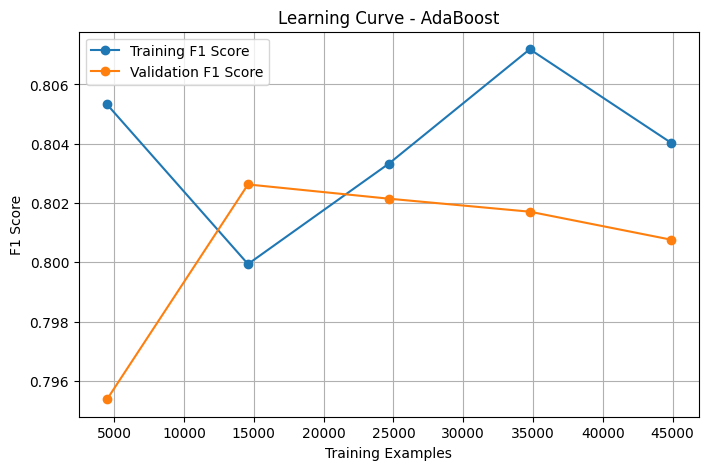

In [ ]:
# ==========================================
# AdaBoost Learning Curve
# ==========================================

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=ada_pipeline_final,
    X=X_train_processed,
    y=y_train,
    cv=3,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Mean scores
train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_scores_mean,
    marker='o',
    label='Training F1 Score'
)

plt.plot(
    train_sizes,
    val_scores_mean,
    marker='o',
    label='Validation F1 Score'
)

plt.title("Learning Curve - AdaBoost")
plt.xlabel("Training Examples")
plt.ylabel("F1 Score")

plt.legend()
plt.grid(True)

plt.show()

# Final comparison graph

,Accuracy,Precision,Recall,F1 Score
Logistic Regression (No PCA),0.955346,0.756536,0.727987,0.741987
MLP (No PCA),0.970739,0.947368,0.707547,0.810081
MLP (Optimized SMOTE),0.963667,0.816949,0.757862,0.786297
Gradient Boosting (No PCA),0.973097,0.986784,0.704403,0.822018
Linear SVM (No PCA),0.961586,0.891921,0.642296,0.746801
RBF SVM (No PCA),0.969075,0.961969,0.676101,0.794090
RBF SVM PSO (No PCA),0.969075,0.969318,0.670597,0.792751
Random Forest (No PCA),0.972889,0.983535,0.704403,0.820889
AdaBoost (Fully Dynamic),0.968936,0.894636,0.734277,0.806563
AdaBoost (Balanced),0.954653,1.000000,0.485849,0.653968


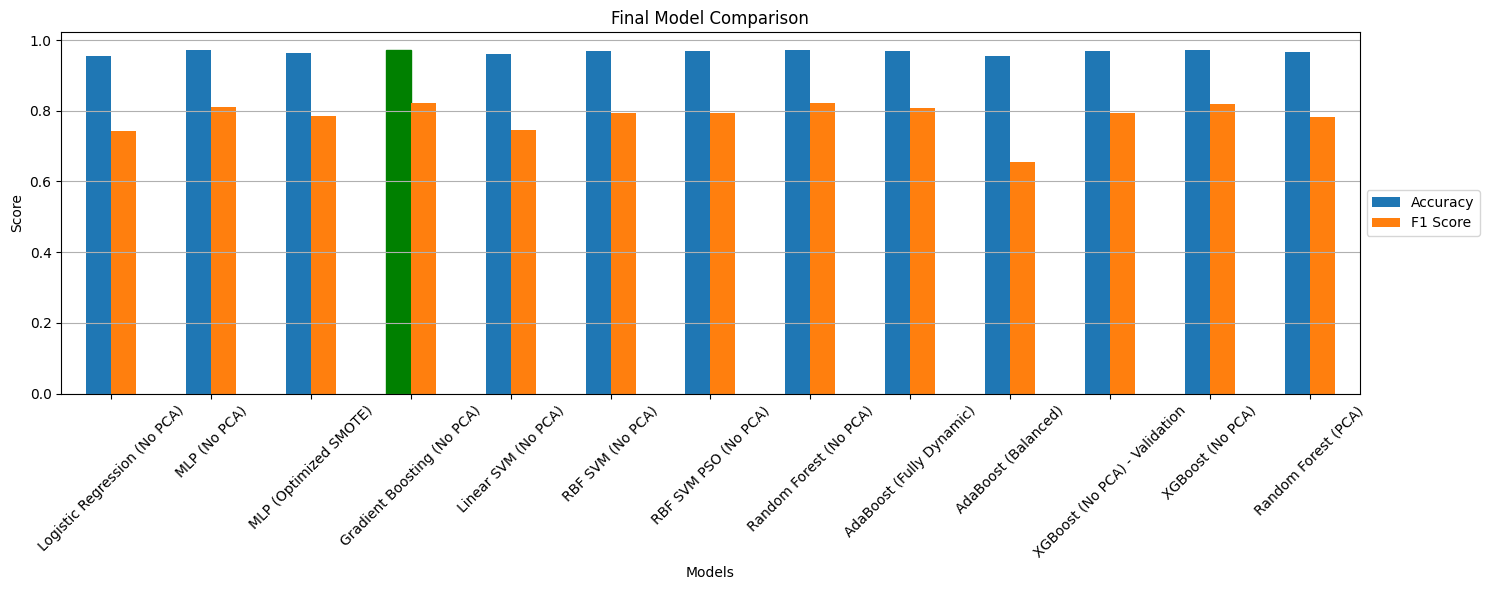

In [ ]:
final_results_df = pd.DataFrame(results).T

# Highlight highest values in table
styled_df = final_results_df.style.highlight_max(
    subset=["Accuracy", "F1 Score"],
    color="lightgreen"
)

display(styled_df)

# Find model with highest Accuracy
best_accuracy_model = final_results_df["Accuracy"].idxmax()

# Create colors
colors = []

for model in final_results_df.index:
    if model == best_accuracy_model:
        colors.append("green")
    else:
        colors.append("skyblue")

# Plot ALL models with Accuracy + F1
ax = final_results_df[["Accuracy","F1 Score"]].plot(
    kind="bar",
    figsize=(15,6)
)

# Highlight best Accuracy bars only
ax.patches[final_results_df.index.get_loc(best_accuracy_model)]\
.set_color("green")

plt.title("Final Model Comparison")
plt.ylabel("Score")
plt.xlabel("Models")

plt.xticks(rotation=45)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1,0.5)
)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# Final Best Model Selection
# ==========================================

final_results_df = pd.DataFrame(results).T

# Choose best model based on F1 Score
best_model_name = final_results_df["F1 Score"].idxmax()

print("===== FINAL SELECTED MODEL =====")
print("Best Model:", best_model_name)

print("\n===== FINAL MODEL METRICS =====")
display(final_results_df.loc[[best_model_name]])

===== FINAL SELECTED MODEL =====
Best Model: Gradient Boosting (No PCA)

===== FINAL MODEL METRICS =====


,Accuracy,Precision,Recall,F1 Score
Gradient Boosting (No PCA),0.973097,0.986784,0.704403,0.822018


In [ ]:
# ==========================================
# Final Model Comparison Table
# ==========================================

final_results_df = pd.DataFrame(results).T

final_results_df = final_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

display(final_results_df)

,Accuracy,Precision,Recall,F1 Score
Gradient Boosting (No PCA),0.973097,0.986784,0.704403,0.822018
Random Forest (No PCA),0.972889,0.983535,0.704403,0.820889
XGBoost (No PCA),0.972473,0.965921,0.713050,0.820443
MLP (No PCA),0.970739,0.947368,0.707547,0.810081
AdaBoost (Fully Dynamic),0.968936,0.894636,0.734277,0.806563
RBF SVM (No PCA),0.969075,0.961969,0.676101,0.794090
XGBoost (No PCA) - Validation,0.969075,0.965129,0.673998,0.793710
RBF SVM PSO (No PCA),0.969075,0.969318,0.670597,0.792751
MLP (Optimized SMOTE),0.963667,0.816949,0.757862,0.786297
Random Forest (PCA),0.966579,0.918432,0.681604,0.782491


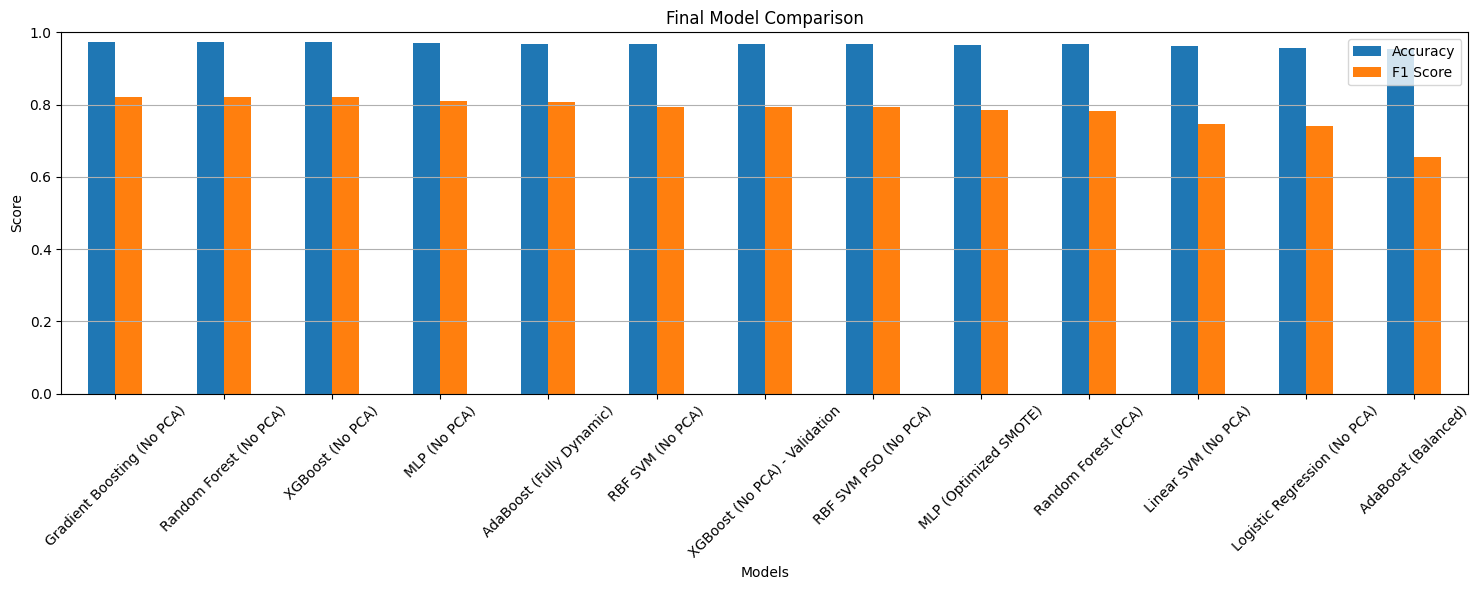

In [ ]:
# ==========================================
# Final Model Comparison Graph
# ==========================================

final_results_df[["Accuracy", "F1 Score"]].plot(
    kind="bar",
    figsize=(15,6)
)

plt.title("Final Model Comparison")
plt.ylabel("Score")
plt.xlabel("Models")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Original number of features: 16
Number of PCA components: 9
Cumulative explained variance: 0.9557218794708624

Random Forest WITH PCA - Validation Results
Accuracy: 0.9632505893773402
Precision: 0.9150837988826815
Recall: 0.6433621366849961
F1 Score: 0.7555350553505535

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13149
           1       0.92      0.64      0.76      1273

    accuracy                           0.96     14422
   macro avg       0.94      0.82      0.87     14422
weighted avg       0.96      0.96      0.96     14422


Random Forest WITH PCA - Test Results
Accuracy: 0.9665788378865622
Precision: 0.9184322033898306
Recall: 0.6816037735849056
F1 Score: 0.7824909747292419

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13150
           1       0.92      0.68      0.78      1272

    accuracy                         

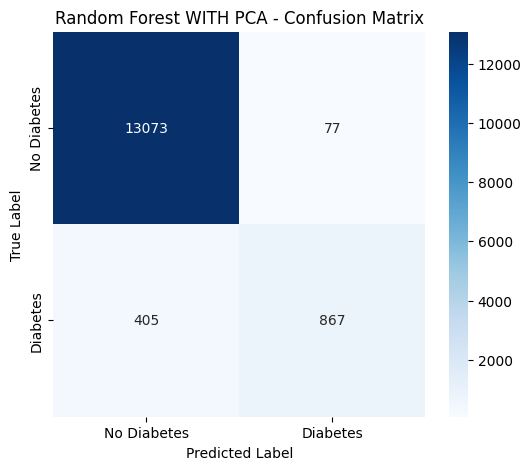

In [ ]:
# ==============================
# RANDOM FOREST WITH PCA
# PCA implemented inside the cell
# ==============================

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize PCA to retain 95% of the variance
rf_pca_transformer = PCA(n_components=0.95, random_state=42)

# 2. Fit PCA ONLY on the training data, then transform train/validation/test
X_train_rf_pca = rf_pca_transformer.fit_transform(X_train_processed)
X_val_rf_pca = rf_pca_transformer.transform(X_val_processed)
X_test_rf_pca = rf_pca_transformer.transform(X_test_processed)

print("Original number of features:", X_train_processed.shape[1])
print("Number of PCA components:", rf_pca_transformer.n_components_)
print("Cumulative explained variance:", rf_pca_transformer.explained_variance_ratio_.sum())

# 3. Initialize Random Forest model
rf_with_pca = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

# 4. Train Random Forest on PCA-transformed training data
rf_with_pca.fit(X_train_rf_pca, y_train)

# 5. Predict on validation and test sets
y_val_pred_rf_pca = rf_with_pca.predict(X_val_rf_pca)
y_test_pred_rf_pca = rf_with_pca.predict(X_test_rf_pca)

# 6. Validation performance
print("\n==============================")
print("Random Forest WITH PCA - Validation Results")
print("==============================")

print("Accuracy:", accuracy_score(y_val, y_val_pred_rf_pca))
print("Precision:", precision_score(y_val, y_val_pred_rf_pca))
print("Recall:", recall_score(y_val, y_val_pred_rf_pca))
print("F1 Score:", f1_score(y_val, y_val_pred_rf_pca))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf_pca))

# 7. Test performance
print("\n==============================")
print("Random Forest WITH PCA - Test Results")
print("==============================")

rf_pca_acc = accuracy_score(y_test, y_test_pred_rf_pca)
rf_pca_precision = precision_score(y_test, y_test_pred_rf_pca)
rf_pca_recall = recall_score(y_test, y_test_pred_rf_pca)
rf_pca_f1 = f1_score(y_test, y_test_pred_rf_pca)

print("Accuracy:", rf_pca_acc)
print("Precision:", rf_pca_precision)
print("Recall:", rf_pca_recall)
print("F1 Score:", rf_pca_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf_pca))

# Save to results dictionary
results["Random Forest (PCA)"] = {
    "Accuracy": rf_pca_acc,
    "F1 Score": rf_pca_f1,
    "Precision": rf_pca_precision,
    "Recall": rf_pca_recall
}

# 8. Confusion Matrix for Test Set
cm_rf_pca = confusion_matrix(y_test, y_test_pred_rf_pca)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf_pca,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title('Random Forest WITH PCA - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# 9. Learning Curve for Random Forest WITH PCA
print("\n==============================")
print("Random Forest WITH PCA - Learning Curve")
print("==============================")

train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf_with_pca,
    X=X_train_rf_pca,
    y=y_train,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Mean scores
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training F1 Score")
plt.plot(train_sizes, val_scores_mean, 'o-', color="g", label="Cross-validation F1 Score")
plt.title('Learning Curve (Random Forest WITH PCA)')
plt.xlabel('Training Examples')
plt.ylabel('F1 Score')
plt.legend(loc="best")
plt.grid(True)
plt.show()


In [ ]:
# ==================================================
# Comparison Plot: Random Forest WITH PCA vs WITHOUT PCA
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve results for both Random Forest models
rf_no_pca_results = results.get("Random Forest (No PCA)", {})
rf_pca_results = results.get("Random Forest (PCA)", {})

# Create a DataFrame for easy plotting
compare_rf_df = pd.DataFrame({
    "Random Forest (No PCA)": rf_no_pca_results,
    "Random Forest (PCA)": rf_pca_results
}).T

display(compare_rf_df)

# Plot the comparison
compare_rf_df[["Accuracy", "F1 Score", "Precision", "Recall"]].plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Random Forest Models: With vs Without PCA")
plt.ylabel("Score")
plt.xlabel("Model Version")
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for scores
plt.xticks(rotation=0)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(axis="y")
plt.tight_layout()
plt.show()
